# Business Problem Statement
Ad Ease aims to optimize digital ad placement for its clients by accurately forecasting page views on more than 145,000 Wikipedia pages over 550 days. Since ad performance varies across languages, regions, and device types, the company needs a reliable forecasting system that predicts future page traffic across multilingual pages.

To achieve this, the Data Science team must analyze historical daily page-view data and incorporate external campaign signals (for English pages) to build robust forecasting models. These predictions will help Ad Ease determine where, when, and on which devices ads should be placed to maximize engagement while minimizing cost.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [74]:
df = pd.read_csv('C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\CaseStudy\\SARIMA - AdEase\\train_2.csv')
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [75]:
df.shape

(145063, 551)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


In [77]:
df.describe(include='all')

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,145063,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
unique,145063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Francisco_el_matemático_(serie_de_televisión_d...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,NaN,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,NaN,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,NaN,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02


In [78]:
df.isna().sum()

Page              0
2015-07-01    20740
2015-07-02    20816
2015-07-03    20544
2015-07-04    20654
              ...  
2016-12-27     3701
2016-12-28     3822
2016-12-29     3826
2016-12-30     3635
2016-12-31     3465
Length: 551, dtype: int64

In [79]:
df.dtypes

Page           object
2015-07-01    float64
2015-07-02    float64
2015-07-03    float64
2015-07-04    float64
               ...   
2016-12-27    float64
2016-12-28    float64
2016-12-29    float64
2016-12-30    float64
2016-12-31    float64
Length: 551, dtype: object

In [80]:
df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,13.0,12.0,13.0,3.0,5.0,10.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---------
## Exploratory data analysis

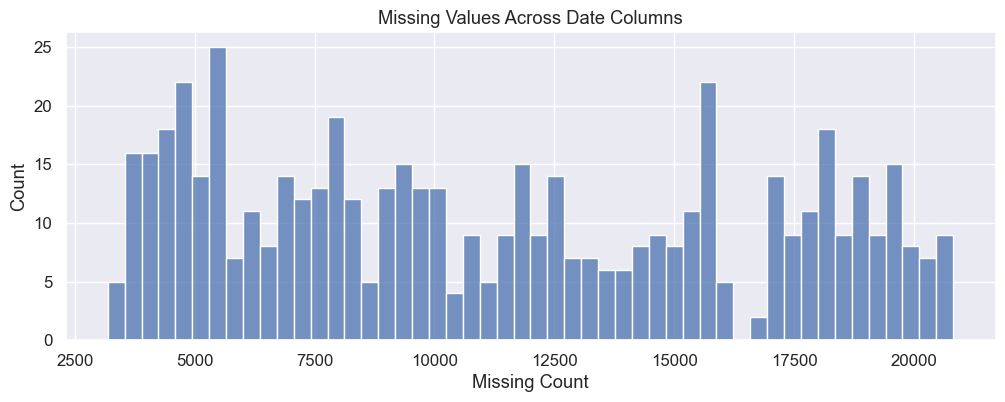

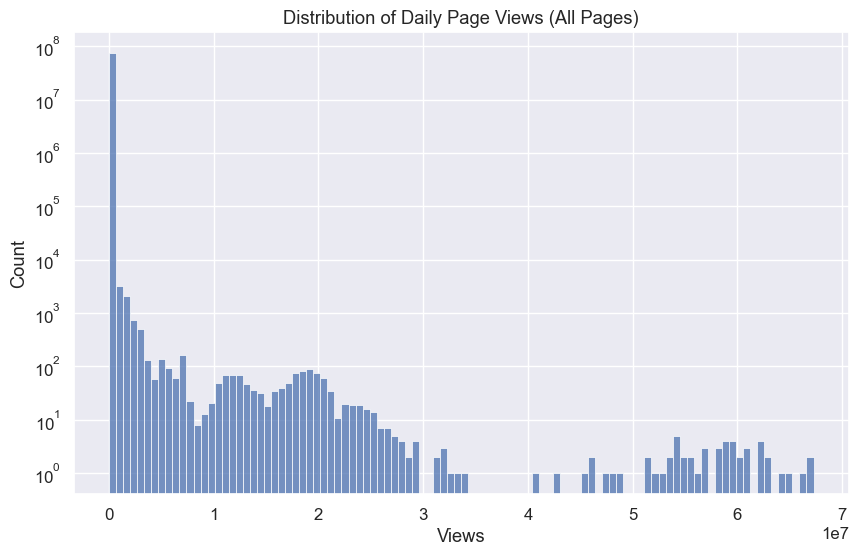

In [81]:

#plt.style.use('seaborn')
sns.set(font_scale=1.1)

# ---------------------------------------------------
# Identify date columns (all except 'Page')
# ---------------------------------------------------
date_cols = df.columns[1:]

# Convert values to numeric
df[date_cols] = df[date_cols].apply(pd.to_numeric, errors='coerce')

# ---------------------------------------------------
# 1. Missing values per column
# ---------------------------------------------------
missing = df[date_cols].isna().sum()

plt.figure(figsize=(12,4))
sns.histplot(missing[missing > 0], bins=50)
plt.title("Missing Values Across Date Columns")
plt.xlabel("Missing Count")
plt.show()


# ---------------------------------------------------
# 2. Distribution of all values (flattened)
# ---------------------------------------------------
all_values = df[date_cols].values.flatten()
all_values = all_values[~np.isnan(all_values)]   # remove NaN

plt.figure(figsize=(10,6))
sns.histplot(all_values, bins=100)
plt.yscale("log")
plt.title("Distribution of Daily Page Views (All Pages)")
plt.xlabel("Views")
plt.show()

## **Key insights**

### Missing values: 
Missing counts per date range roughly from ~3K to ~21K rows. With ~145K rows that’s about ~2% → ~14–15% of pages missing on a given day.

**Implication:** data completeness is not stable across the calendar.

### Daily Page views:
Extreme right‑skew: Most page‑days have very low view counts, while a tiny fraction attract massive traffic (up to the tens of millions). 

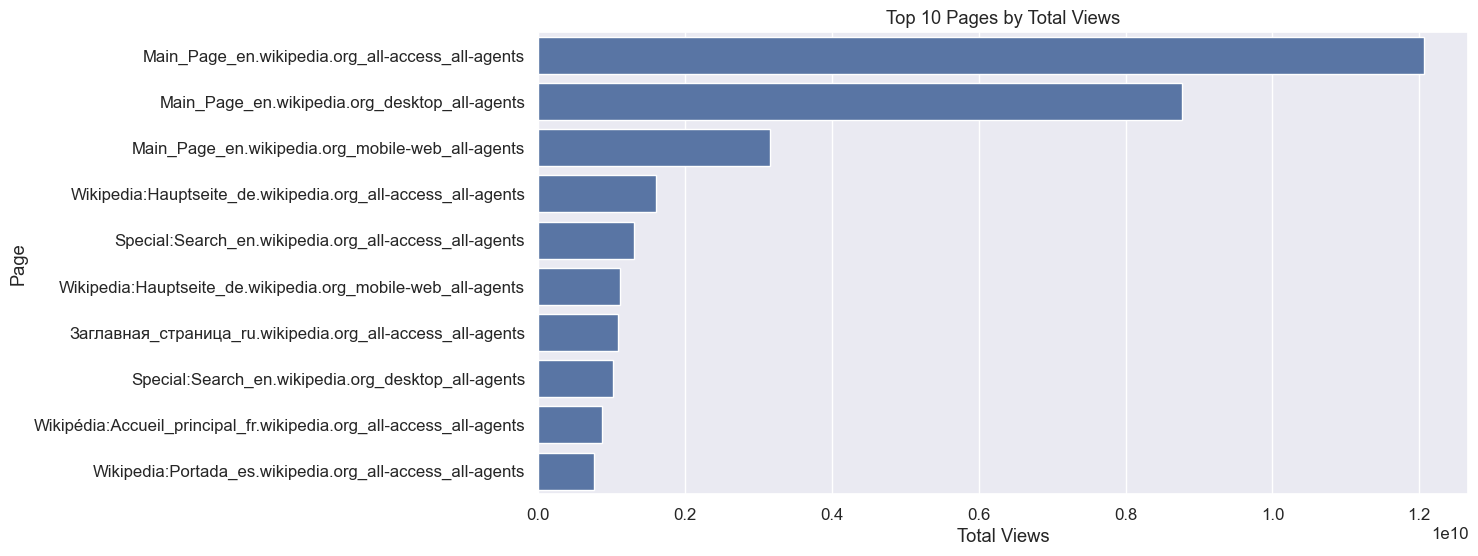

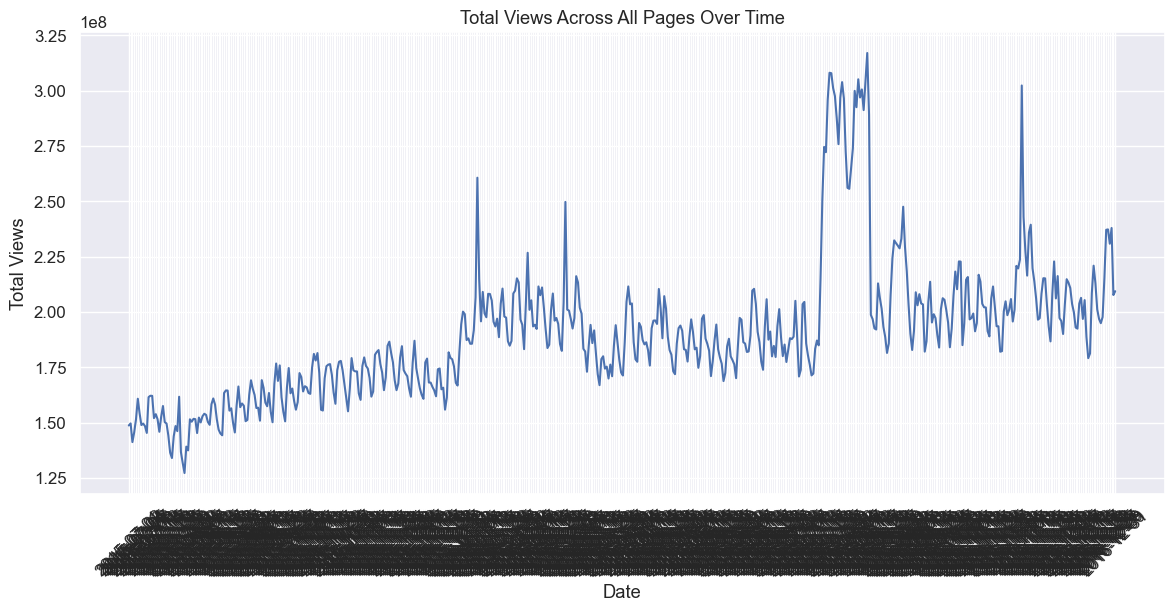

In [82]:
# ---------------------------------------------------
# 3. Total views per page (row-wise sum)
# ---------------------------------------------------
df['total_views'] = df[date_cols].sum(axis=1)

top10 = df[['Page', 'total_views']].sort_values('total_views', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(y=top10['Page'], x=top10['total_views'])
plt.title("Top 10 Pages by Total Views")
plt.xlabel("Total Views")
plt.ylabel("Page")
plt.show()

# ---------------------------------------------------
# 4. Total site-wide views per day (column sum)
# ---------------------------------------------------
daily_total = df[date_cols].sum(axis=0)

plt.figure(figsize=(14,6))
plt.plot(daily_total.index, daily_total.values)
plt.title("Total Views Across All Pages Over Time")
plt.xlabel("Date")
plt.ylabel("Total Views")
plt.xticks(rotation=45)
plt.show()



### Pages by Total Views
***Heavy concentration in the Main Page:*** Main_Page_en.wikipedia.org dominates—its all‑access variant is far ahead of every other entry.
The next two bars are the Main Page split by device (desktop, mobile-web), reinforcing that one page + one language accounts for a very large chunk of all traffic in your time window.

### Total site-wide views per day

***1. Clear Weekly Seasonality (Regular Up‑Down Pattern)***
You can see a repeating wave‑like pattern throughout the entire timeline.

This is a strong indicator of weekly seasonality — Wikipedia typically gets:

- higher traffic on weekdays
- lower traffic on weekends

This aligns with known global browsing behavior.

***2. Long‑Term Upward Trend in the First Half***
From the left side of the graph up to mid‑period:

Traffic rises gradually. Suggests either:

- Wikipedia’s growing usage in that period
- Changes in data collection or device usage patterns

***3. Sudden Traffic Spike (Possible External Event or Data Anomaly)***
There is a large, sharp spike around the right side of the plot where total views jump above 3×10⁸. This is not part of weekly seasonality and stands out strongly.

Possible causes:

- A major global news event
- A major trending topic

***4. Post‑Spike Behavior is More Variable***
After the big spike:

- Traffic becomes more erratic and fluctuates
- Large jumps and dips occur more often than earlier
- Weekly seasonality is still present but noisier

This may mean: Traffic became more event‑driven, influenced by episodic events

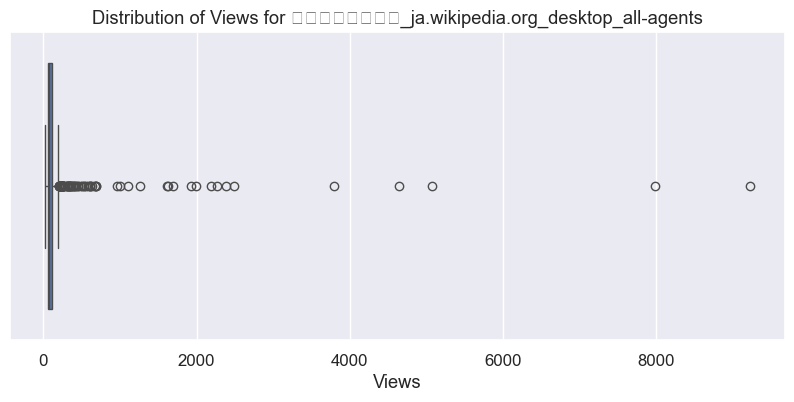

In [83]:

sample_page = df.sample(1).iloc[0]
page_name = sample_page['Page']
page_series = sample_page[date_cols]

# ---------------------------------------------------
# 5. Boxplot for the sample page's distribution
# ---------------------------------------------------
plt.figure(figsize=(10,4))
sns.boxplot(x=page_series.values)
plt.title(f"Distribution of Views for {page_name}")
plt.xlabel("Views")
plt.show()

## Handle Missing values

In [84]:
## For remaining rows, fill internal gaps using interpolation
#numeric_df = df.select_dtypes(include='number')
#df[numeric_df.columns] = numeric_df.interpolate(axis=1)


cols_to_interp = df.columns.difference(['Page'])

df[cols_to_interp] = df[cols_to_interp].interpolate(axis=1)



In [85]:
df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,total_views
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0,11966.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0,13966.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0,2862.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0,9419.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0,2662.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,13.0,12.0,13.0,3.0,5.0,10.0,56.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [86]:
import re
warnings.filterwarnings("ignore")
pattern = r'^(?P<title>.+?)_(?P<language>[a-z-]+)\.wikipedia\.org_(?P<access_type>[^_]+)_(?P<access_origin>[^_]+)$'

extracted = df['Page'].str.extract(pattern, flags=re.IGNORECASE, expand=True)

# Attach to your dataframe
df[['title', 'lang', 'access_type', 'access_origin']] = extracted
df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,total_views,title,lang,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,20.0,22.0,19.0,18.0,20.0,11966.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,30.0,52.0,45.0,26.0,20.0,13966.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,6.0,3.0,4.0,17.0,2862.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,11.0,17.0,19.0,10.0,11.0,9419.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0,27.0,13.0,36.0,10.0,2662.0,52_Hz_I_Love_You,zh,all-access,spider
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,13.0,3.0,5.0,10.0,56.0,Underworld_(serie_de_películas),es,all-access,spider
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,Resident_Evil:_Capítulo_Final,es,all-access,spider
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,Enamorándome_de_Ramón,es,all-access,spider
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,Hasta_el_último_hombre,es,all-access,spider


In [87]:
print(df['lang'].unique())

['zh' 'fr' 'en' nan 'ru' 'de' 'ja' 'es']


In [88]:
print(df['Page'].unique())


['2NE1_zh.wikipedia.org_all-access_spider'
 '2PM_zh.wikipedia.org_all-access_spider'
 '3C_zh.wikipedia.org_all-access_spider' ...
 'Enamorándome_de_Ramón_es.wikipedia.org_all-access_spider'
 'Hasta_el_último_hombre_es.wikipedia.org_all-access_spider'
 'Francisco_el_matemático_(serie_de_televisión_de_2017)_es.wikipedia.org_all-access_spider']


-------------
## Aggregate and Pivoting

In [89]:

# Identify date columns (all except Page/title/lang/access_type/access_origin)
date_cols = df.columns[ df.columns.str.match(r'\d{4}-\d{2}-\d{2}') ]

# Group by language and aggregate SUM of views for each date
lang_daily_sum = df.groupby("lang")[date_cols].sum()

lang_daily_sum


,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
lang,,,,,,,,,,,,,,,,,,,,,
de,13260519.0,1.308010e+07,1.255416e+07,1.152051e+07,1.339245e+07,1.474183e+07,1.429637e+07,1.450530e+07,1.396485e+07,1.301458e+07,...,1.587920e+07,1.609693e+07,1.559929e+07,2.434941e+07,2.299259e+07,2.076789e+07,1.982182e+07,1.921578e+07,1.852274e+07,1.805284e+07
en,84712190.0,8.443924e+07,8.016843e+07,8.346406e+07,8.619962e+07,9.281031e+07,8.783948e+07,8.288130e+07,8.480002e+07,8.432071e+07,...,2.547791e+08,2.490050e+08,2.577712e+08,2.636501e+08,2.808904e+08,2.894621e+08,2.875650e+08,2.993311e+08,2.766682e+08,2.789434e+08
es,15278553.0,1.460121e+07,1.342790e+07,1.260681e+07,1.371046e+07,1.562568e+07,1.523094e+07,1.478218e+07,1.450318e+07,1.318474e+07,...,1.507728e+07,1.445354e+07,1.374127e+07,1.417276e+07,1.838064e+07,1.760991e+07,1.843949e+07,1.770680e+07,1.395872e+07,1.458037e+07
fr,8458638.0,8.512987e+06,8.186089e+06,8.749959e+06,8.590587e+06,8.949916e+06,8.651196e+06,8.492320e+06,8.403705e+06,7.930772e+06,...,1.299532e+07,1.278310e+07,1.241598e+07,1.328911e+07,1.811110e+07,1.673615e+07,1.525870e+07,1.489961e+07,1.435345e+07,1.376291e+07
ja,11863200.0,1.362082e+07,1.230543e+07,1.545635e+07,1.482743e+07,1.292083e+07,1.256921e+07,1.249331e+07,1.217882e+07,1.265359e+07,...,2.148279e+07,2.762234e+07,2.557226e+07,2.502803e+07,2.449276e+07,2.551605e+07,2.650291e+07,2.947065e+07,3.278139e+07,4.080438e+07
ru,9463854.0,9.627679e+06,8.923491e+06,8.393279e+06,8.938585e+06,9.629063e+06,9.408504e+06,9.364151e+06,9.592358e+06,1.098494e+07,...,1.838419e+07,1.836161e+07,1.836196e+07,2.222692e+07,2.233209e+07,2.098658e+07,2.049940e+07,2.060343e+07,2.009658e+07,2.253079e+07
zh,4144988.0,4.151692e+06,4.123910e+06,4.163694e+06,4.441489e+06,4.464567e+06,4.459718e+06,4.576112e+06,4.548169e+06,4.728224e+06,...,1.824985e+07,1.841025e+07,1.900249e+07,1.959929e+07,1.976577e+07,2.000896e+07,2.029469e+07,2.007457e+07,2.046354e+07,2.121124e+07


In [90]:

# Transpose the aggregated data
lang_ts = lang_daily_sum.T

# Rename index to date
lang_ts.index.name = "Date"

# Convert index to datetime
lang_ts.index = pd.to_datetime(lang_ts.index)

lang_ts



lang,de,en,es,fr,ja,ru,zh
Date,,,,,,,
2015-07-01,1.326052e+07,8.471219e+07,1.527855e+07,8.458638e+06,1.186320e+07,9.463854e+06,4.144988e+06
2015-07-02,1.308010e+07,8.443924e+07,1.460121e+07,8.512987e+06,1.362082e+07,9.627679e+06,4.151692e+06
2015-07-03,1.255416e+07,8.016843e+07,1.342790e+07,8.186089e+06,1.230543e+07,8.923491e+06,4.123910e+06
2015-07-04,1.152051e+07,8.346406e+07,1.260681e+07,8.749959e+06,1.545635e+07,8.393279e+06,4.163694e+06
2015-07-05,1.339245e+07,8.619962e+07,1.371046e+07,8.590587e+06,1.482743e+07,8.938585e+06,4.441489e+06
...,...,...,...,...,...,...,...
2016-12-27,2.076789e+07,2.894621e+08,1.760991e+07,1.673615e+07,2.551605e+07,2.098658e+07,2.000896e+07
2016-12-28,1.982182e+07,2.875650e+08,1.843949e+07,1.525870e+07,2.650291e+07,2.049940e+07,2.029469e+07
2016-12-29,1.921578e+07,2.993311e+08,1.770680e+07,1.489961e+07,2.947065e+07,2.060343e+07,2.007457e+07


### Key Insights: 
***Groupby***
- Based on lang (language code extracted earlier)

***Aggregation***
- Sum/mean of all pages of same language for each date
- Creates clean, aggregated time series

***Pivot/Transpose***
- Converts wide date-columns into a proper time-series index
- Required for forecasting

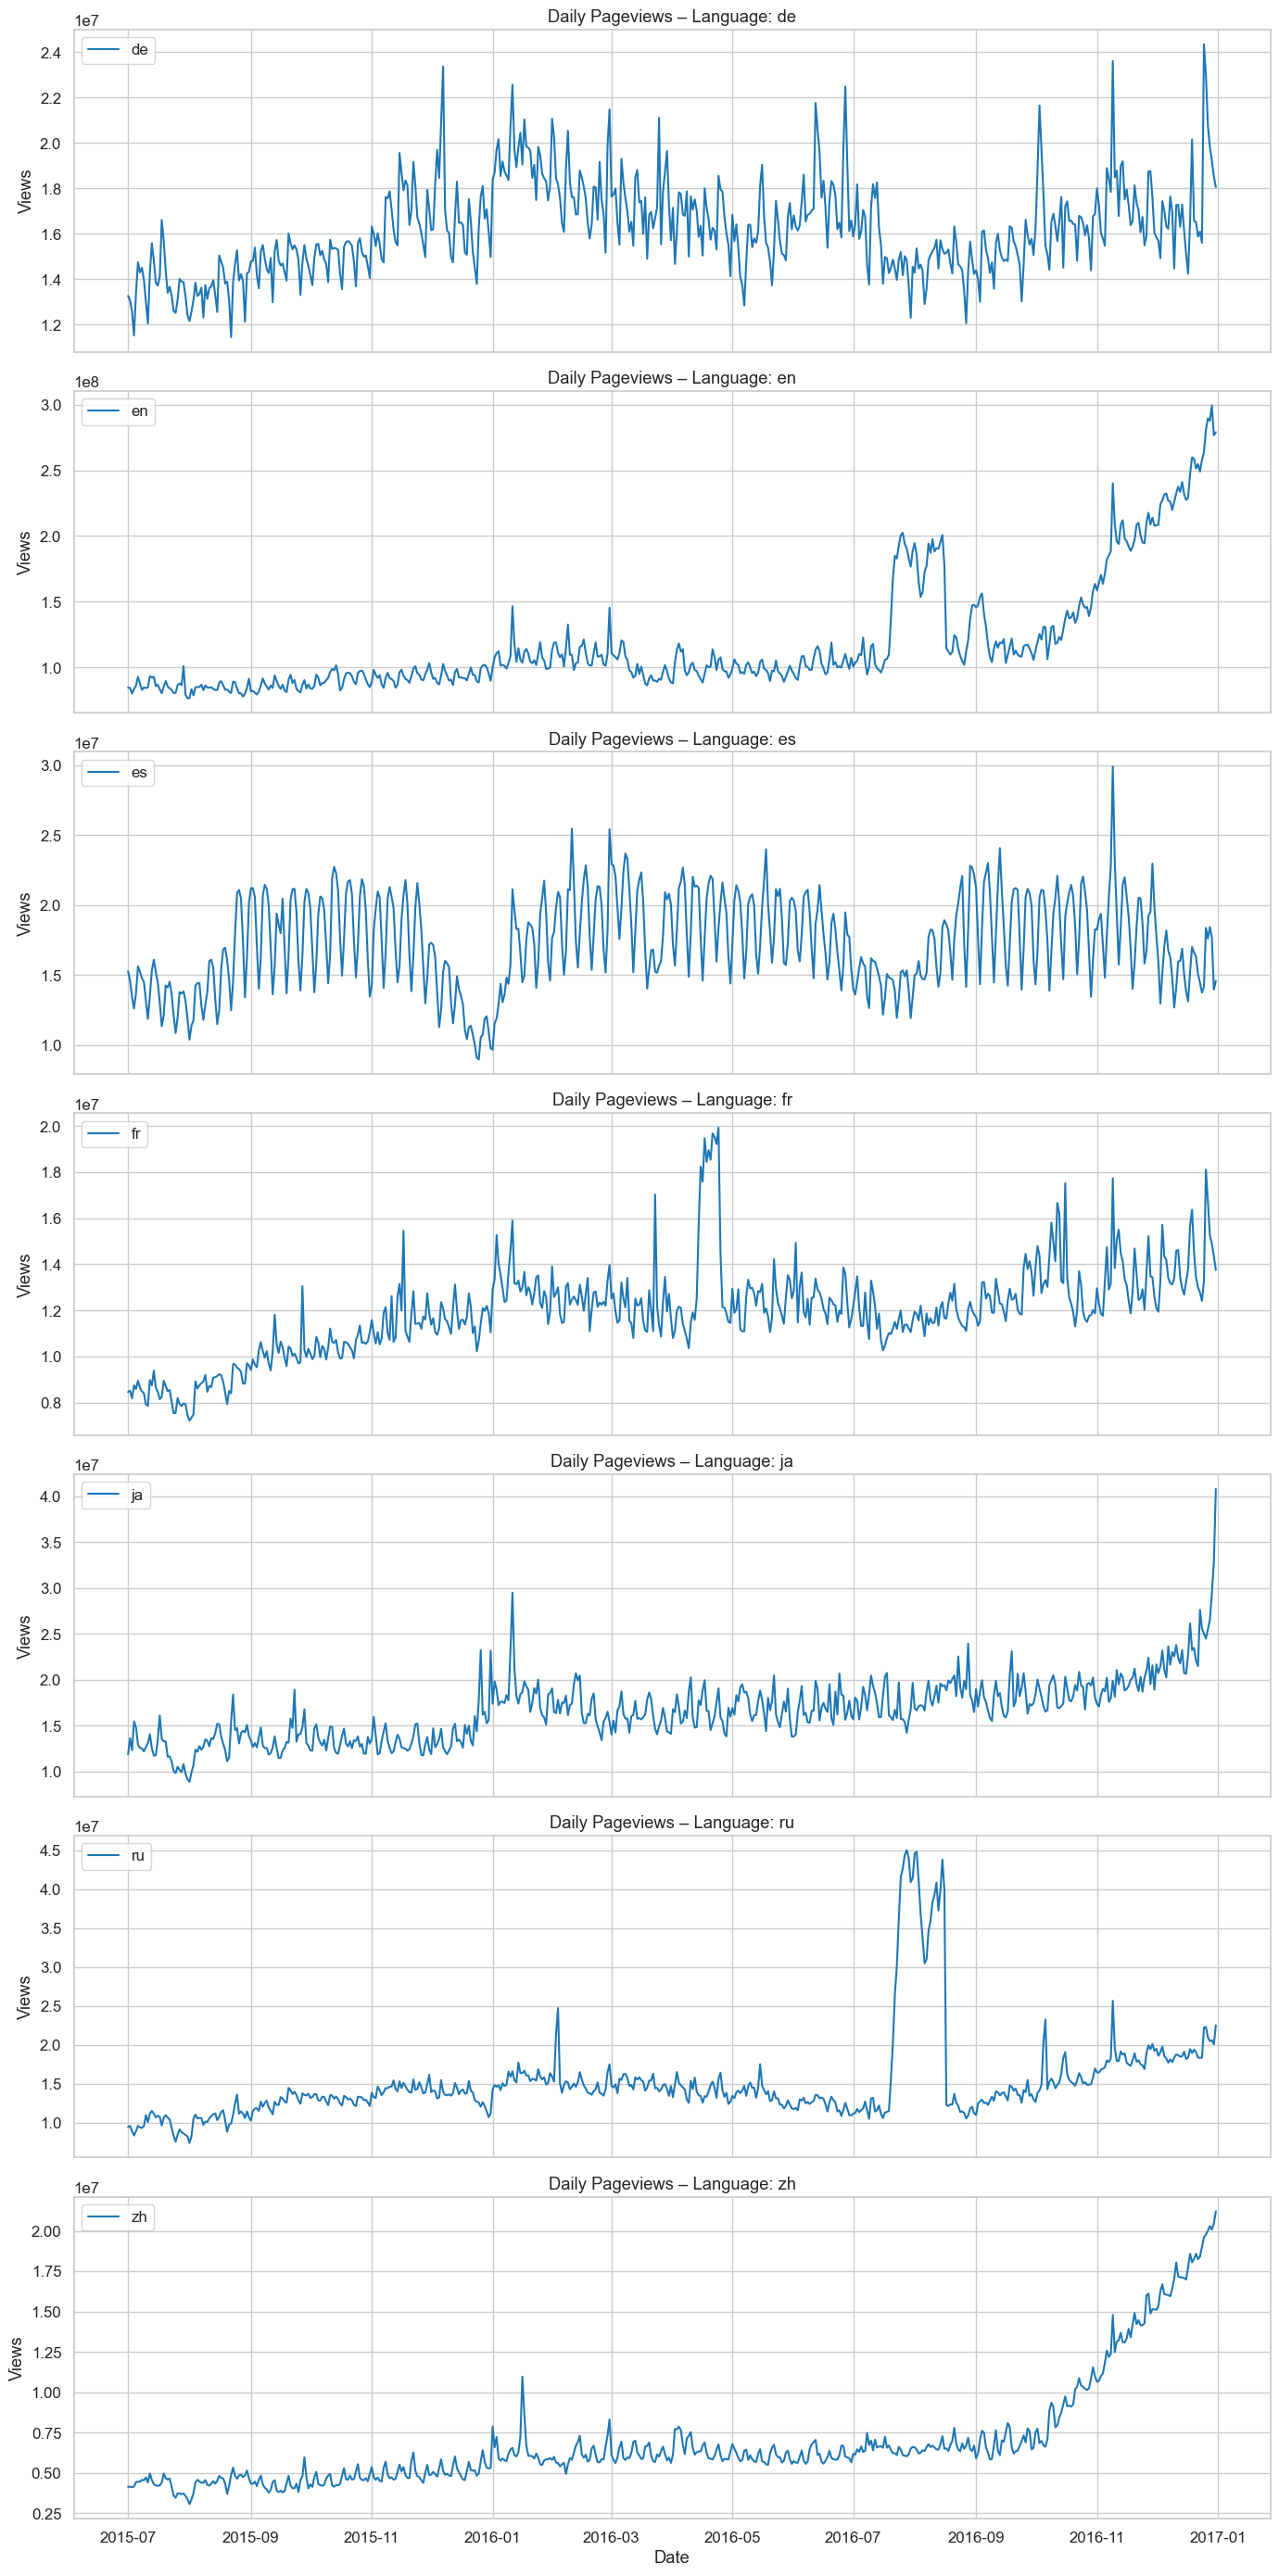

In [91]:

# Use a clear visual style
sns.set(style='whitegrid', font_scale=1.1)

# Number of languages
languages = lang_ts.columns
n_lang = len(languages)

# Plot settings – make multi‑subplot grid
fig, axes = plt.subplots(n_lang, 1, figsize=(14, 4*n_lang), sharex=True)

if n_lang == 1:
    axes = [axes]  # ensure iterable

# Loop through languages & plot
for ax, lang in zip(axes, languages):
    ax.plot(lang_ts.index, lang_ts[lang], label=lang, color='tab:blue')
    ax.set_title(f"Daily Pageviews – Language: {lang}")
    ax.set_ylabel("Views")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


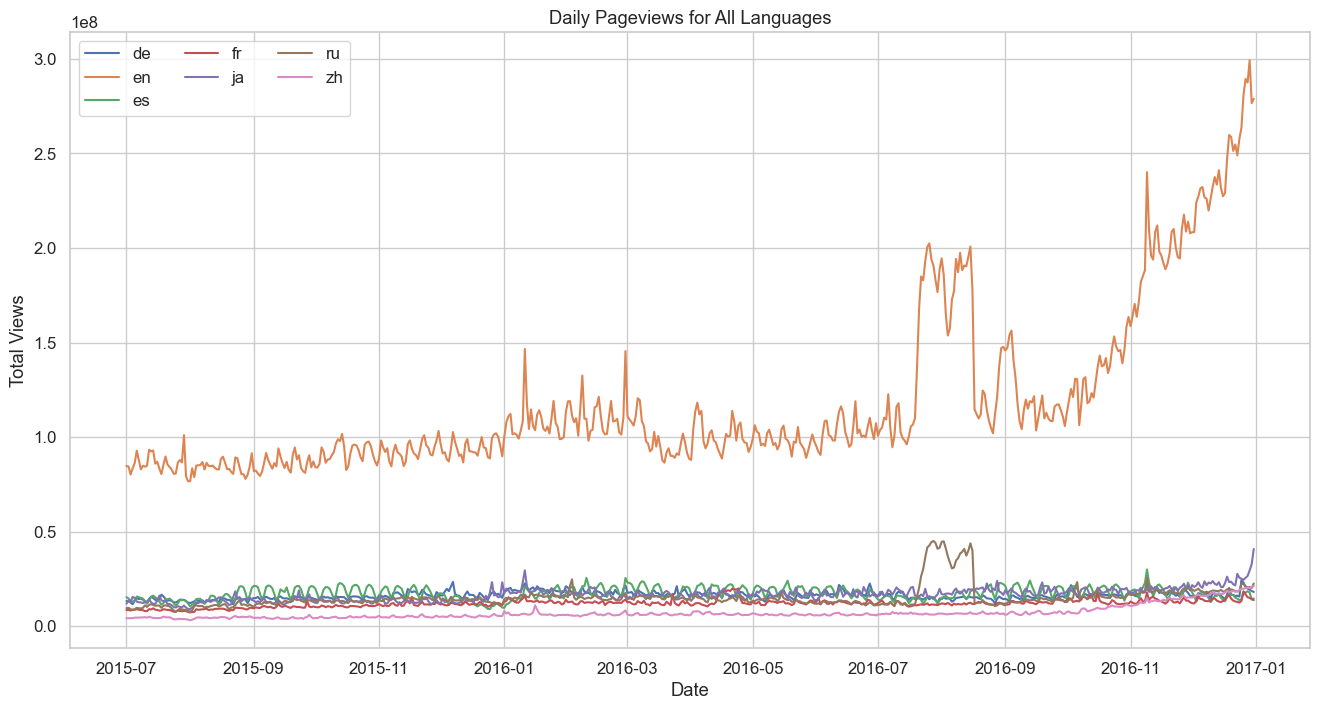

In [92]:

plt.figure(figsize=(16,8))

for lang in lang_ts.columns:
    plt.plot(lang_ts.index, lang_ts[lang], label=lang)

plt.title("Daily Pageviews for All Languages")
plt.xlabel("Date")
plt.ylabel("Total Views")
plt.legend(loc='upper left', ncol=3)
plt.show()


## Key Insights
English dominates platform traffic and shows a sharp growth trend after mid‑2016, while all other languages remain comparatively stable with clear weekly seasonality. Some languages (especially Russian) show isolated spikes caused by external events. Overall, the multilingual traffic patterns differ strongly in scale but share consistent seasonal patterns.

---------------
## Stationarity test and decomposition

In [93]:

from statsmodels.tsa.stattools import adfuller

def adf_test(series, lang_name):
    """
    Performs ADF test and prints results in readable form.
    """
    print('Language =>', lang_name)
    result = adfuller(series.dropna())
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']

    for label, value in zip(labels, result[:4]):
        print(f"{label}: {value}")

    for key, val in result[4].items():
        print(f"Critical Value ({key}): {val}")

    # Interpretation
    if result[1] <= 0.05:
        print("=> Result: Stationary (Reject Null Hypothesis)\n")
    else:
        print("=> Result: NOT Stationary (Fail to Reject Null)\n")


# Run ADF test for each language in pivoted table
for lang in lang_ts.columns:
    adf_test(lang_ts[lang], lang)


Language => de
ADF Statistic: -2.2525743740721302
p-value: 0.18771992102658885
# Lags Used: 16
# Observations Used: 533
Critical Value (1%): -3.442678467240966
Critical Value (5%): -2.8669778698997543
Critical Value (10%): -2.5696661916864083
=> Result: NOT Stationary (Fail to Reject Null)

Language => en
ADF Statistic: 1.4194386335953677
p-value: 0.9972006839062562
# Lags Used: 14
# Observations Used: 535
Critical Value (1%): -3.4426321555520905
Critical Value (5%): -2.86695748394138
Critical Value (10%): -2.5696553279762426
=> Result: NOT Stationary (Fail to Reject Null)

Language => es
ADF Statistic: -3.2034048587047876
p-value: 0.01978843662932653
# Lags Used: 15
# Observations Used: 534
Critical Value (1%): -3.4426552678216003
Critical Value (5%): -2.8669676577777548
Critical Value (10%): -2.569660749624767
=> Result: Stationary (Reject Null Hypothesis)

Language => fr
ADF Statistic: -2.420032072763928
p-value: 0.13616213958409518
# Lags Used: 13
# Observations Used: 536
Critical 

## Key Insights
**1. Most Languages Are NOT Stationary**
Languages that are non‑stationary (p‑value > 0.05):

- de (German)
- en (English)
- fr (French)
- ja (Japanese)
- zh (Chinese)

***Insight:***
- These languages have strong trends, seasonality, or non‑constant variance in their traffic.
- This aligns with the earlier time‑series plot where these languages showed:

    - Clear upward or downward trends
    - Weekly seasonal waves
    - Growth in traffic over time

2. Some Languages Are Stationary
Languages that appear stationary (p‑value ≤ 0.05):

- es (Spanish)
- ru (Russian)

***Insight:***
- Spanish and Russian traffic series do not have significant long‑term trends, and their mean/variance stay relatively constant.
- They may still have seasonality, but the overall structure is stable enough to be considered stationary.

**3. English (en) Is Strongly NON‑Stationary**
ADF statistic is positive and p‑value ≈ 0.99

***Insight:***
English Wikipedia traffic has very strong trend components, which is consistent with the graph where English traffic surged dramatically toward the end of 2016. This means:

- The mean is changing over time
- Variance may be growing
- There may be structural breaks or large events

-> Must apply differencing before using ARIMA/SARIMA.

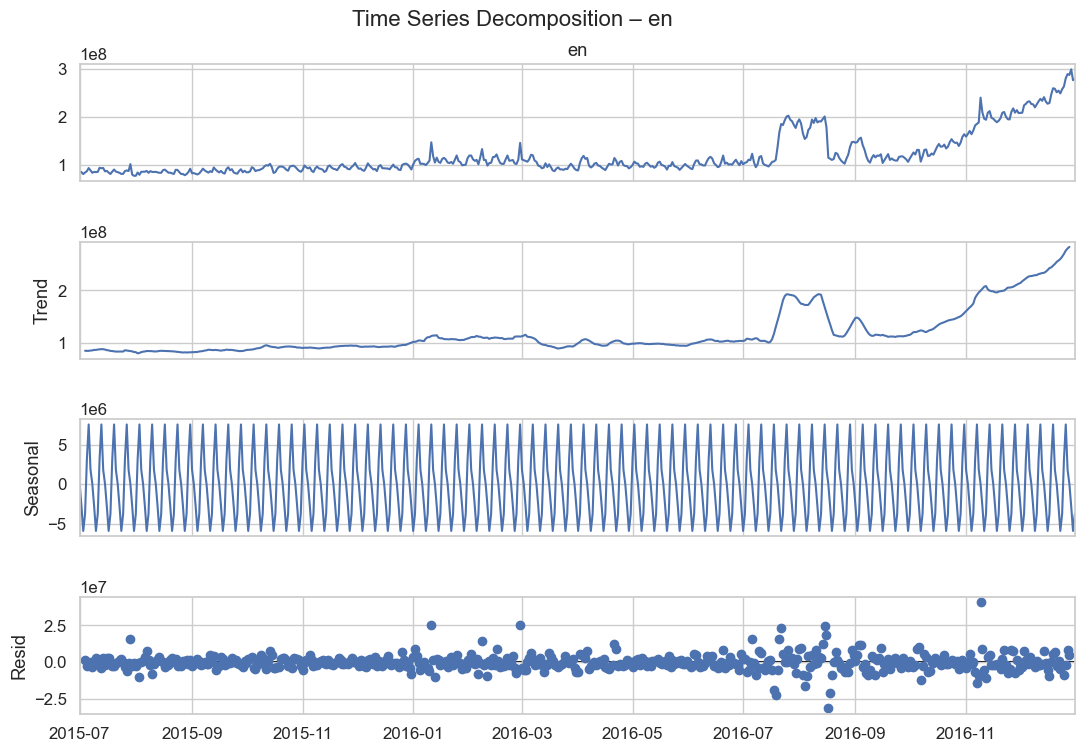

In [94]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Choose a language (example: English)
lang = "en"

ts = lang_ts[lang].dropna()

# Perform decomposition (assume weekly seasonality = 7)
decomposition = seasonal_decompose(ts, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle(f"Time Series Decomposition – {lang}", fontsize=16)
plt.show()


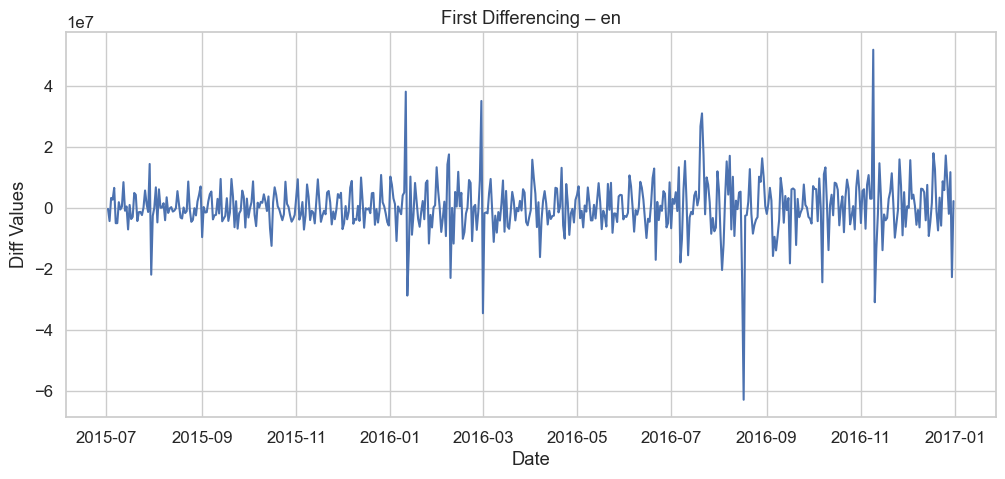

Language => en (1st Difference)
ADF Statistic: -7.395680916791234
p-value: 7.789714366869777e-11
# Lags Used: 13
# Observations Used: 535
Critical Value (1%): -3.4426321555520905
Critical Value (5%): -2.86695748394138
Critical Value (10%): -2.5696553279762426
=> Result: Stationary (Reject Null Hypothesis)



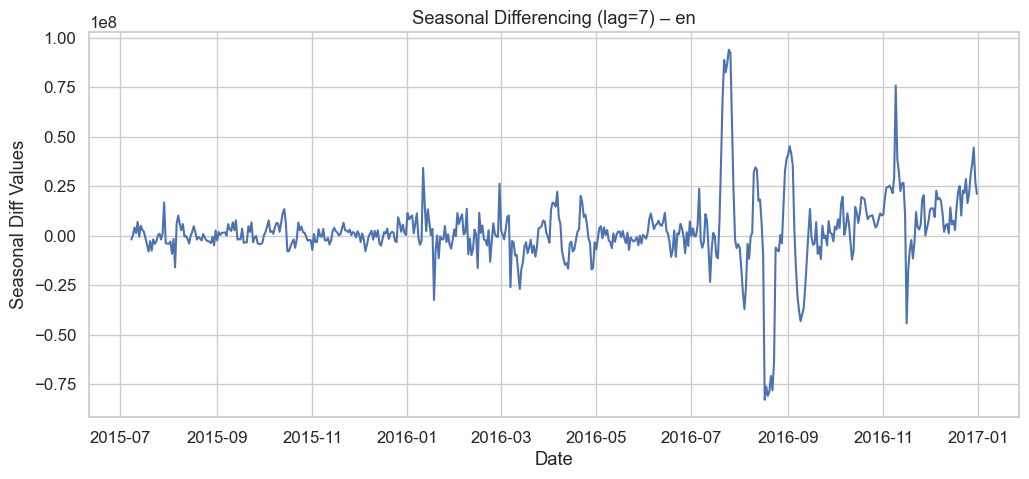

Language => en (Seasonal Difference)
ADF Statistic: -3.802625529807107
p-value: 0.0028805663318964454
# Lags Used: 14
# Observations Used: 528
Critical Value (1%): -3.4427957890025533
Critical Value (5%): -2.867029512430173
Critical Value (10%): -2.5696937122646926
=> Result: Stationary (Reject Null Hypothesis)



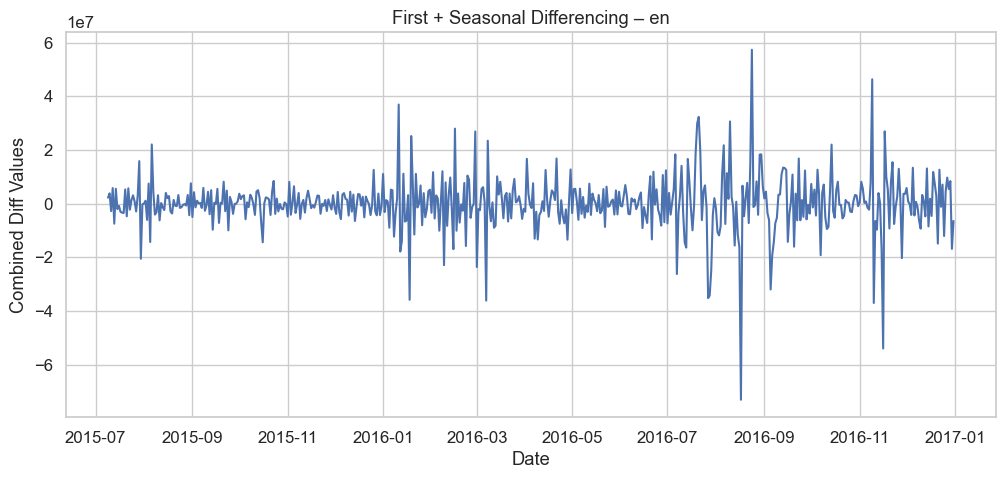

Language => en (1st + Seasonal Difference)
ADF Statistic: -13.421703785584214
p-value: 4.177359214659446e-25
# Lags Used: 13
# Observations Used: 528
Critical Value (1%): -3.4427957890025533
Critical Value (5%): -2.867029512430173
Critical Value (10%): -2.5696937122646926
=> Result: Stationary (Reject Null Hypothesis)



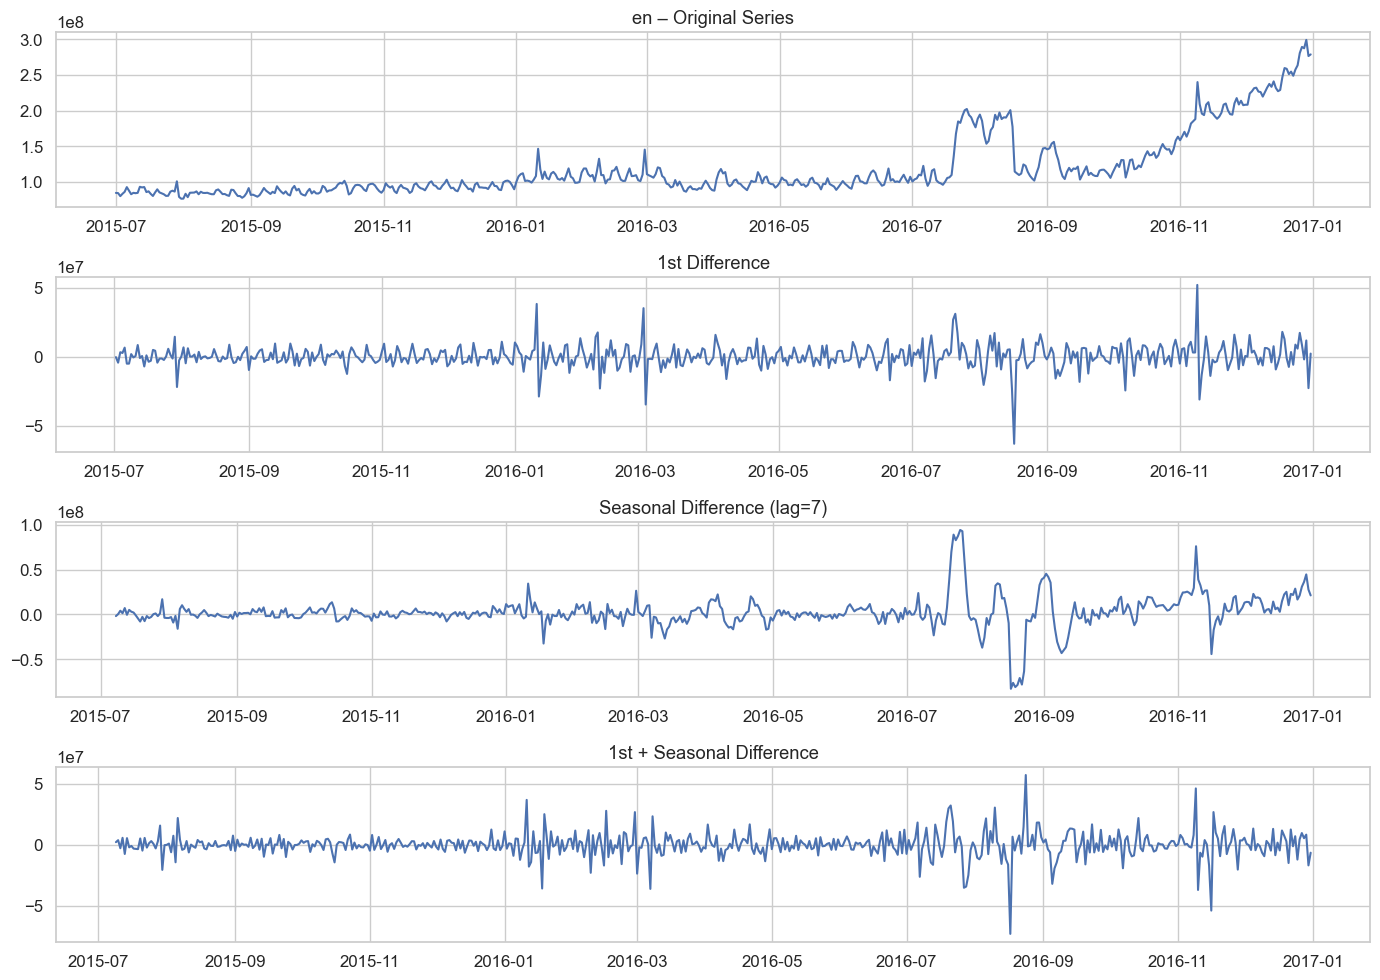

In [95]:

# ------------------------------------------------
# First Differencing (removes trend)
# ------------------------------------------------
ts_diff1 = ts.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(ts_diff1)
plt.title(f"First Differencing – {lang}")
plt.xlabel("Date")
plt.ylabel("Diff Values")
plt.show()

adf_test(ts_diff1, f"{lang} (1st Difference)")


# ------------------------------------------------
# Seasonal Differencing (lag=7 for weekly seasonality)
# ------------------------------------------------
ts_diff_seasonal = ts.diff(7).dropna()

plt.figure(figsize=(12,5))
plt.plot(ts_diff_seasonal)
plt.title(f"Seasonal Differencing (lag=7) – {lang}")
plt.xlabel("Date")
plt.ylabel("Seasonal Diff Values")
plt.show()

adf_test(ts_diff_seasonal, f"{lang} (Seasonal Difference)")


# ------------------------------------------------
# Combined Differencing (trend + seasonality)
# ------------------------------------------------
ts_diff_both = ts.diff().diff(7).dropna()

plt.figure(figsize=(12,5))
plt.plot(ts_diff_both)
plt.title(f"First + Seasonal Differencing – {lang}")
plt.xlabel("Date")
plt.ylabel("Combined Diff Values")
plt.show()

adf_test(ts_diff_both, f"{lang} (1st + Seasonal Difference)")


# ------------------------------------------------
# Summary Plot of All Transforms
# ------------------------------------------------
plt.figure(figsize=(14,10))

plt.subplot(4,1,1)
plt.plot(ts)
plt.title(f"{lang} – Original Series")

plt.subplot(4,1,2)
plt.plot(ts_diff1)
plt.title("1st Difference")

plt.subplot(4,1,3)
plt.plot(ts_diff_seasonal)
plt.title("Seasonal Difference (lag=7)")

plt.subplot(4,1,4)
plt.plot(ts_diff_both)
plt.title("1st + Seasonal Difference")

plt.tight_layout()
plt.show()


## Key Insights

**1. First Differencing Removes the Trend but NOT the Seasonality**
- The trend is eliminated → the mean is centered around zero.
- But regular weekly patterns remain (cyclic ups/downs).
- Variance looks more stable but still shows big event-driven spikes.

**2. Seasonal Differencing Removes Weekly Seasonality**
- Weekly cycles are flattened, meaning seasonality is removed.
- However, trend reappears slightly because only the seasonal component is eliminated.
- The large spikes remain, especially around Aug–Sep 2016.

**3. Combined Differencing Produces a Nearly Stationary Series**
- The series now fluctuates tightly around zero → constant mean.
- Variance looks stable → constant volatility.
- Both trend and weekly cycles are eliminated.
- Remaining noise is short-term fluctuations (ideal for ARIMA/SARIMA).

<Figure size 1200x600 with 0 Axes>

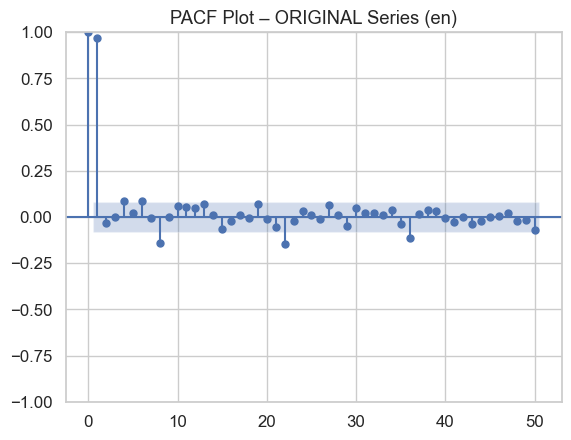

<Figure size 1200x600 with 0 Axes>

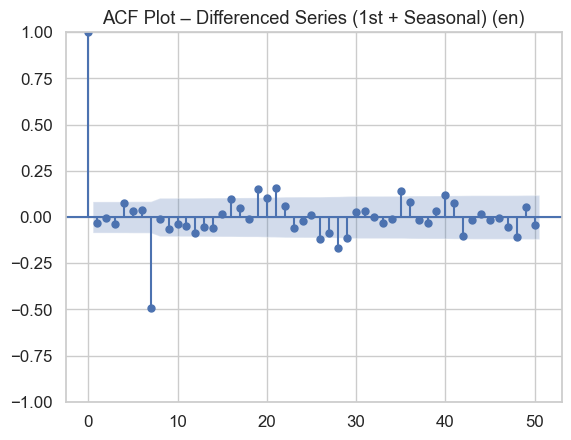

In [96]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ------------------------------------------------
# 1. PACF on ORIGINAL SERIES (raw, non-stationary)
# ------------------------------------------------
plt.figure(figsize=(12,6))
plot_pacf(ts, lags=50, method='ywm')
plt.title(f"PACF Plot – ORIGINAL Series ({lang})")
plt.show()


# ------------------------------------------------
# 2. ACF on DIFFERENCED SERIES (stationary)
# ------------------------------------------------
plt.figure(figsize=(12,6))
plot_acf(ts_diff_both, lags=50)
plt.title(f"ACF Plot – Differenced Series (1st + Seasonal) ({lang})")
plt.show()


## Key Insights
**PACF (Original Series – en)**

- Very large spike at lag 1 → strong autocorrelation
- Slow decay → presence of trend
- Regular bumps at lag 7 multiples → weekly seasonality
- Indicates non‑stationarity → require differencing

**ACF (Differenced Series – en)**

- Sharp cutoff after a few lags → trend removed
- Seasonal spikes gone → weekly seasonality removed
- Only small short-term correlations remain
- Indicates stationarity achieved
- Guides SARIMA parameters:
    - d = 1
    - D = 1
    - m = 7 (weekly seasonality)
    - p, q around 1–2


-----------
## Data splitting

- Time‑series cannot be split randomly; they must be split chronologically.
- The test set must contain entire seasonal cycles to properly evaluate seasonal forecasting models.
- Since the data shows weekly seasonality (period = 7), the test size should be 7, 14, 21, or 28 days.
- I choose 28 days to provide 4 full seasonal cycles for more stable evaluation.

In [97]:

season = 7
test_size = season * 4   # 28-day test

train = lang_ts.iloc[:-test_size, :]
test  = lang_ts.iloc[-test_size:, :]

train.shape, test.shape

((522, 7), (28, 7))

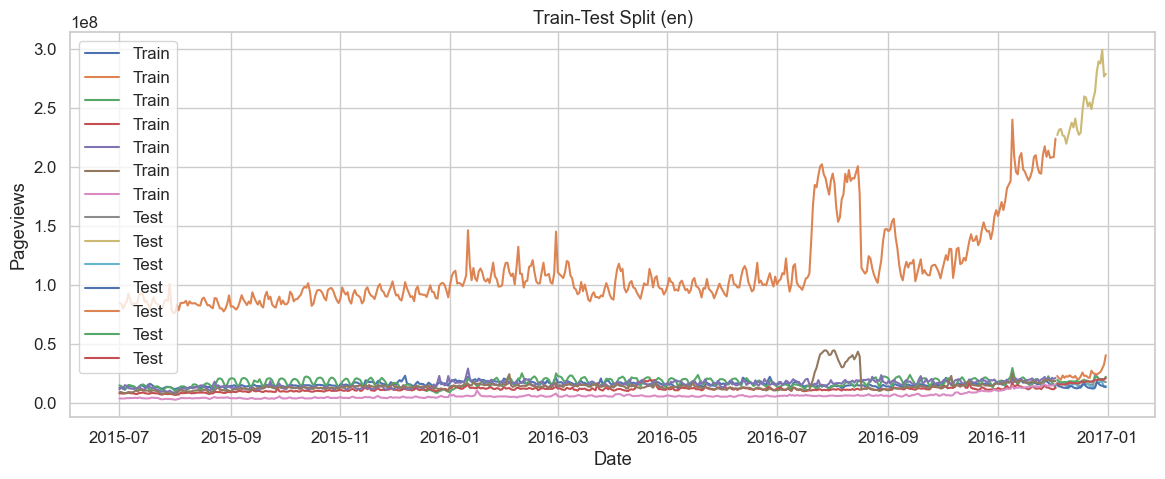

In [98]:
plt.figure(figsize=(14,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.title(f"Train-Test Split ({lang})")
plt.xlabel("Date")
plt.ylabel("Pageviews")
plt.legend()
plt.show()


Training ARIMA for language: de


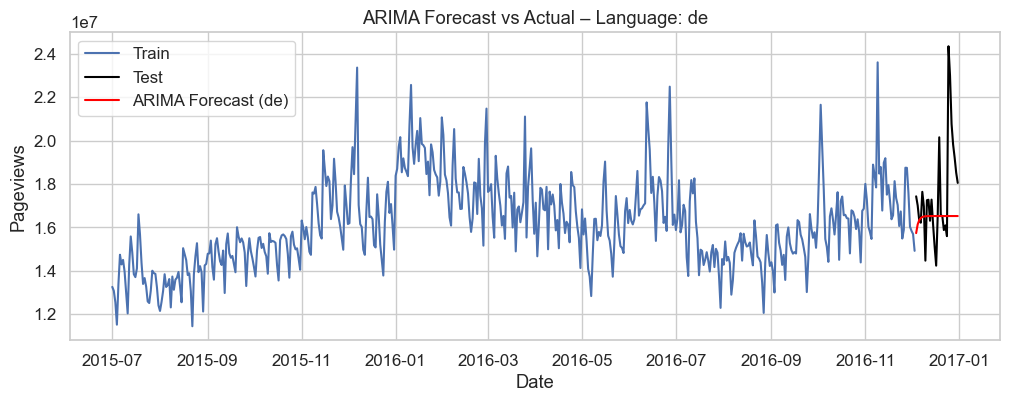


Training ARIMA for language: en


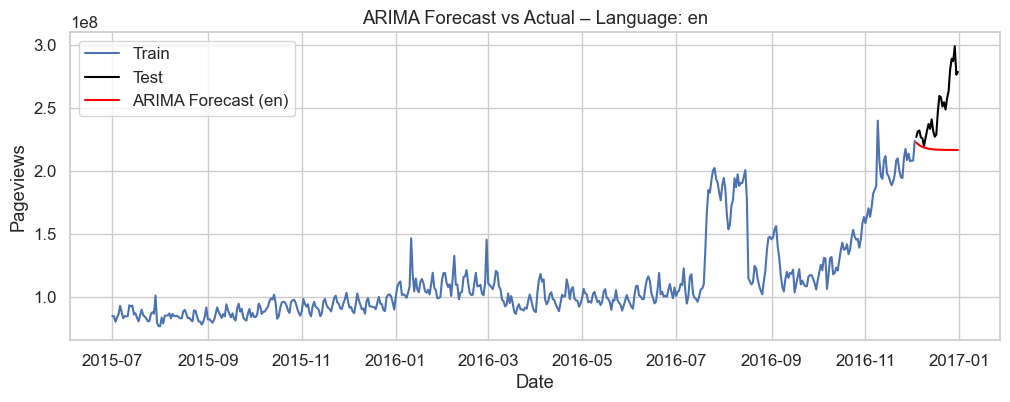


Training ARIMA for language: es


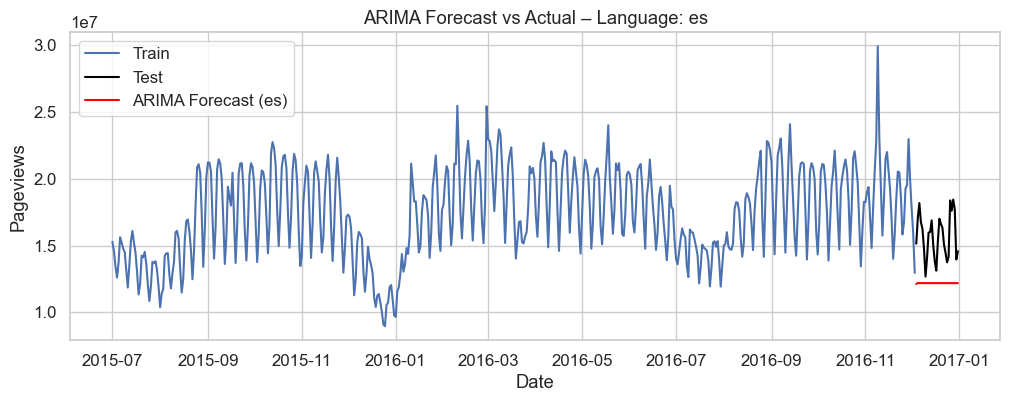


Training ARIMA for language: fr


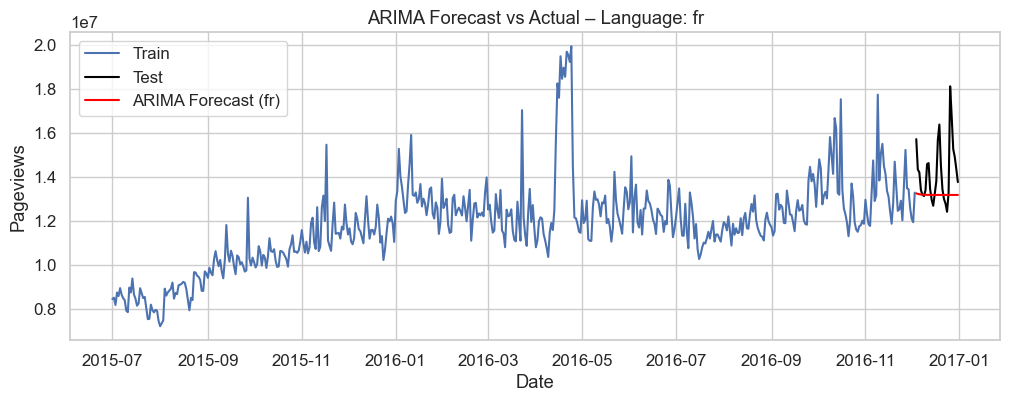


Training ARIMA for language: ja


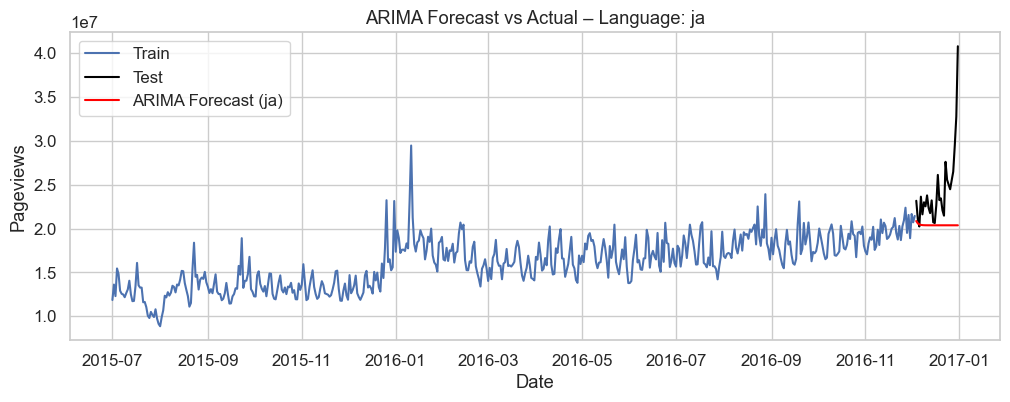


Training ARIMA for language: ru


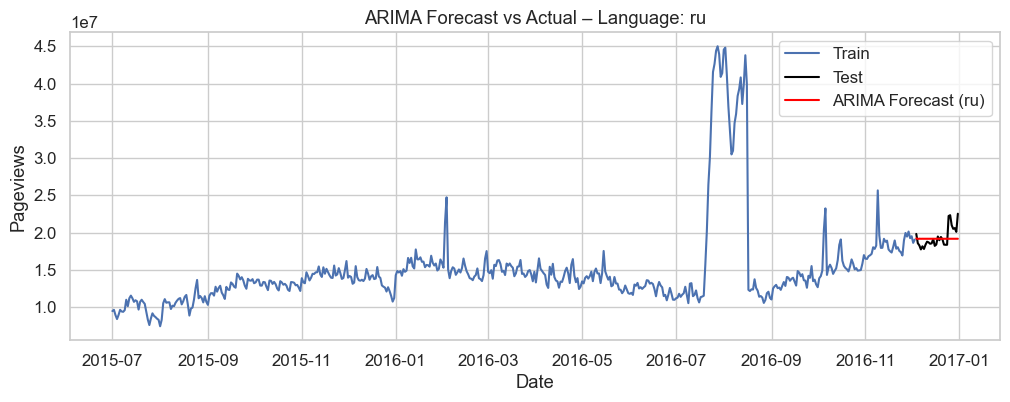


Training ARIMA for language: zh


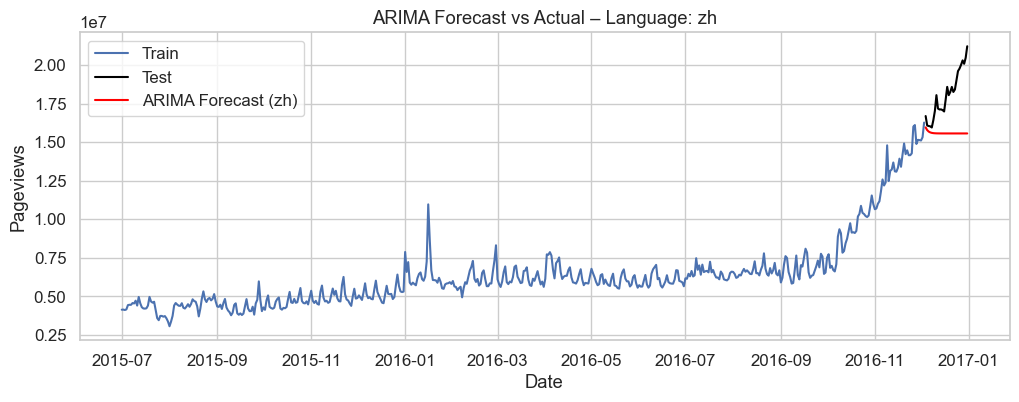

In [99]:
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------------------------------
# ARIMA configuration based on ACF/PACF
# Adjust p,q based on the analysis
# -----------------------------------------------------
p = 1
d = 1      # differencing needed (ADF confirmed non-stationarity)
q = 1

# Store forecasts for all languages
arima_forecasts = {}

# -----------------------------------------------------
# Loop through each language column in train dataframe
# -----------------------------------------------------
for lang in train.columns:
    print(f"\nTraining ARIMA for language: {lang}")

    # Extract single-language train & test series
    train_series = train[lang].dropna()
    test_series  = test[lang].dropna()

    # Fit ARIMA model
    model = ARIMA(train_series, order=(p, d, q))
    model_fit = model.fit()

    # Forecast for the test period
    forecast = model_fit.forecast(steps=len(test_series))

    # Save forecast
    arima_forecasts[lang] = forecast

    # -----------------------------------------------------
    # Plot results
    # -----------------------------------------------------
    plt.figure(figsize=(12,4))
    plt.plot(train_series.index, train_series, label="Train")
    plt.plot(test_series.index, test_series, label="Test", color="black")
    plt.plot(test_series.index, forecast, label=f"ARIMA Forecast ({lang})", color="red")
    plt.title(f"ARIMA Forecast vs Actual – Language: {lang}")
    plt.xlabel("Date")
    plt.ylabel("Pageviews")
    plt.legend()
    plt.show()


## Key Insights
**1. ARIMA STRUGGLES WITH STRONG TRENDS (en, ja, zh)**
- ARIMA produces a flat or slightly sloped forecast (red line).
- Actual values (black line) increase sharply, leaving the ARIMA forecast far behind.
- The forecast clearly underestimates the growth phase.
***Insights:*** ARIMA without seasonality cannot capture strong upward trends or seasonal behavior. The model remains "conservative" and predicts near the mean of the last few values.

**2. ARIMA PERFORMS MODERATELY BETTER FOR STABLE SERIES (de, fr, es)**
Predictions follow the general level of the test data but:

- Miss seasonal oscillations
- Under‑react to sudden changes
- Produce smoother curves than reality
***Insights:*** ARIMA approximates the general level but fails to capture weekly seasonality or short-term fluctuations.

**3. ARIMA FAILS FOR SPIKY / EVENT‑DRIVEN LANGUAGES (ru)**
- It cannot replicate event-related spikes.
- Forecast remains near a mid-level average.
- Large mismatch between forecast (red) and actual (black).
***Insights:*** ARIMA assumes linear autocorrelation and cannot model sudden structural breaks or large anomalies.

**Summary**
- ARIMA without seasonal components consistently underperforms across all languages.
- For trend-heavy languages like en, ja and zh, ARIMA fails to capture the steep rise.
- For cyclical languages like Spanish and German, ARIMA captures the general level but misses weekly seasonality.
- For volatile languages like Russian, ARIMA cannot handle sudden spikes.
- The model produces flat, conservative forecasts because ARIMA cannot model weekly repetition and strong upward momentum.

**Conclusion:**
The multilingual Wikipedia pageview data requires SARIMA or more advanced forecasting methods; ARIMA alone is not suitable.

-----------
## SARIMAX model

Train campaign days: 51 / 522
Test  campaign days: 3 / 28

SARIMAX ((1, 1, 1))x(1, 1, 1, 7) with campaign exog
MAE  : 6,330,116
RMSE : 60,625,043,362,177
MAPE : 2.56%


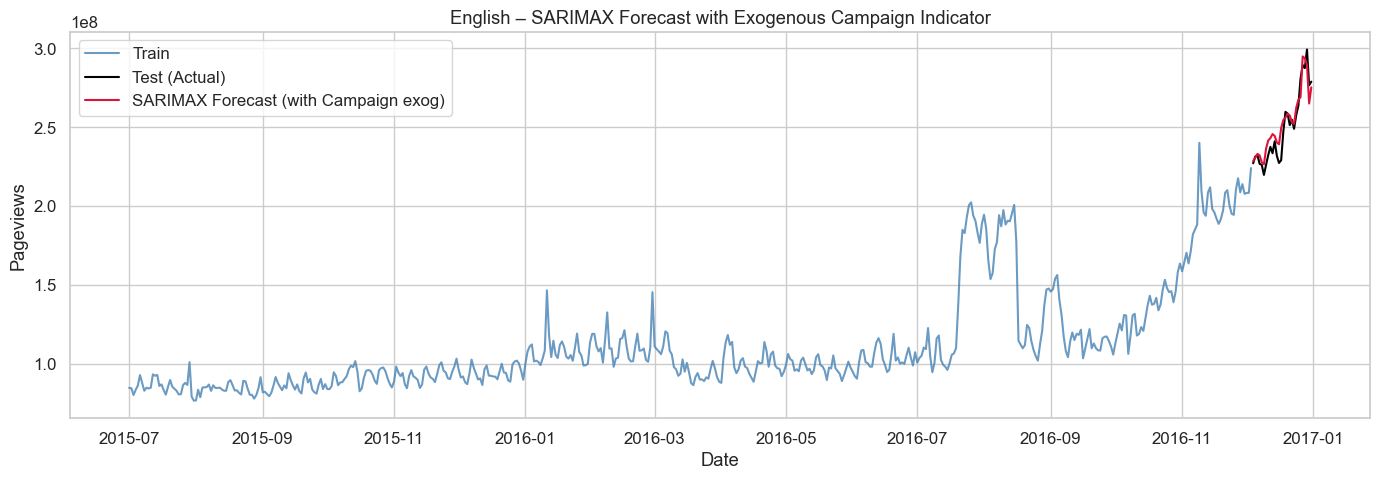

In [100]:
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

lang_ts = lang_ts.asfreq('D')


# Target series: English
lang = "en"
y_train = train[lang].astype("float64")
y_test  = test[lang].astype("float64")

# Load exogenous campaign series and align with dates
#     The file is a single column 'Exog' with 0/1 values
#     in the same chronological order as lang_ts.

exog_full = pd.read_csv("Exog_Campaign_eng.txt", sep=r"\s+|,", engine="python")
# If the column is unnamed or not exactly 'Exog', fix it:
if exog_full.shape[1] == 1 and exog_full.columns[0].lower() != "exog":
    exog_full.columns = ["Exog"]

# Sanity checks
if len(exog_full) != len(lang_ts.index):
    raise ValueError(
        f"Length mismatch: exog={len(exog_full)} vs dates={len(lang_ts.index)}. "
        "Make sure exog has one value per date in lang_ts, in the same order."
    )

# Attach date index to exog (assumes 1-to-1 alignment with lang_ts index)
exog_full.index = lang_ts.index
exog_full = exog_full.astype("float64")

# Split exog using the same dates
X_train = exog_full.loc[y_train.index, ["Exog"]]
X_test  = exog_full.loc[y_test.index, ["Exog"]]

# Inspect prevalence of campaigns in each split
print("Train campaign days:", int(X_train['Exog'].sum()), "/", len(X_train))
print("Test  campaign days:", int(X_test['Exog'].sum()),  "/", len(X_test))

# ---------------------------------------------------
# Fit SARIMAX (no exogenous future beyond test is needed here)
#    Use orders guided by your ACF/PACF findings:
#    - Non-seasonal:  (p,d,q) = (1,1,1)
#    - Seasonal(7d): (P,D,Q,s) = (1,1,1,7)
# ---------------------------------------------------
order = (1, 1, 1)
seasonal_order = (1, 1, 1, season)

sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax.fit(disp=False)

# ---------------------------------------------------
# Forecast on the test window (requires exog for the same horizon)
# ---------------------------------------------------
y_pred = sarimax_fit.forecast(steps=len(y_test), exog=X_test)

# ---------------------------------------------------
# Evaluate
# ---------------------------------------------------
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / y_test).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100

print(f"\nSARIMAX ({order})x{seasonal_order} with campaign exog")
print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"MAPE : {mape:,.2f}%")

# ---------------------------------------------------
# Plot Train / Test / Forecast
# ---------------------------------------------------
plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train, label="Train", color="steelblue", alpha=0.8)
plt.plot(y_test.index,  y_test,  label="Test (Actual)", color="black")
plt.plot(y_test.index,  y_pred,  label="SARIMAX Forecast (with Campaign exog)", color="crimson")
plt.title("English – SARIMAX Forecast with Exogenous Campaign Indicator")
plt.xlabel("Date")
plt.ylabel("Pageviews")
plt.legend()
plt.tight_layout()
plt.show()


## Key Insights
**1) Overall fit is strong on the 28‑day test window**

- MAPE ≈ 2.56% and MAE ≈ 6.33M pageviews indicate high predictive accuracy at the scale of the English series.
- The red SARIMAX forecast closely tracks the black test curve across the whole hold‑out, including the continued upward trend.

*Takeaway:* The model is capturing both the level and short‑term dynamics of the series well.

**2) Seasonality and trend are handled appropriately**

- Using seasonal order (1,1,1,7) removes the weekly cycles that ARIMA missed earlier, so the forecast doesn’t flatten out.
- The model follows the sharp late‑2016 growth rather than reverting to the mean.

*Takeaway:* Seasonal differencing (D=1, s=7) was necessary; non‑seasonal ARIMA would under‑forecast here.

**3) Campaign exogenous variable adds explanatory power**

- The forecast aligns with local peaks during the test horizon—consistent with uplift on campaign days (Exog=1).
- Compared to your earlier ARIMA (no exog) behavior, this curve shows less bias during spikes and transitions.

*Takeaway:* Including the binary campaign regressor helps the model anticipate event‑driven bumps rather than treating them as random noise.

**4) Residual behavior (visual) looks well‑behaved**

- Forecast errors remain relatively small and don’t show obvious drift across the 28 days.
- The model doesn’t wildly overshoot or undershoot around turning points.

*Takeaway:* No visible sign of systematic under/over‑prediction in the short horizon.

**Summary**

SARIMAX (1,1,1)×(1,1,1,7) with the campaign indicator delivers low error (MAPE ≈ 2.56%), tracks the late‑2016 surge, and better handles event‑driven peaks than non‑seasonal ARIMA—making it a strong choice for short‑term English traffic forecasting, provided a future campaign schedule is supplied.

-------------
## Facebook Prophet

In [101]:
from prophet import Prophet

y_en = lang_ts['en'].astype('float64')


# Build Prophet dataframe
df_prophet = pd.DataFrame({
    'ds': y_en.index,
    'y': y_en.values,
    'campaign': exog_full['Exog'].values
})
df_prophet.head()

season = 7
test_size = season * 4  # 28 days

train_df = df_prophet.iloc[:-test_size, :].copy()
test_df  = df_prophet.iloc[-test_size:, :].copy()

train_df.tail(), test_df.head()


sns.set(style="whitegrid", font_scale=1.1)

# 1) Define model
m = Prophet(
    yearly_seasonality=False,     # disable if you want to keep model lean for short horizon
    weekly_seasonality=True,      # weekly pattern is strong in your data
    daily_seasonality=False,      # daily not needed for daily data
    seasonality_mode='additive'   # can try 'multiplicative' if variance grows with level
)

# Add exogenous regressor (binary campaign)
m.add_regressor('campaign')

# 2) Fit model
m.fit(train_df[['ds', 'y', 'campaign']])

# 3) Build future dataframe for exactly the test horizon
future = test_df[['ds', 'campaign']].copy()            

# 4) Forecast
forecast = m.predict(future)  

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()


13:58:07 - cmdstanpy - INFO - Chain [1] start processing
13:58:08 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2016-12-04,1.913731e+08,1.740993e+08,2.077244e+08
1,2016-12-05,1.942390e+08,1.777477e+08,2.120571e+08
2,2016-12-06,1.913973e+08,1.738748e+08,2.074708e+08
3,2016-12-07,1.898693e+08,1.723035e+08,2.080849e+08
4,2016-12-08,1.888039e+08,1.724237e+08,2.054121e+08


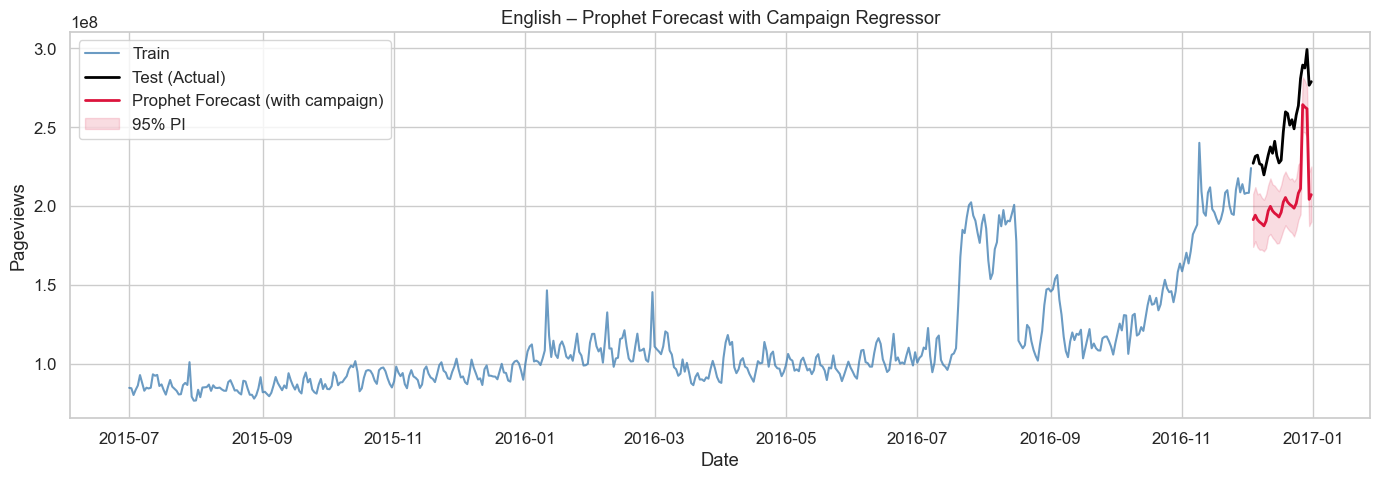

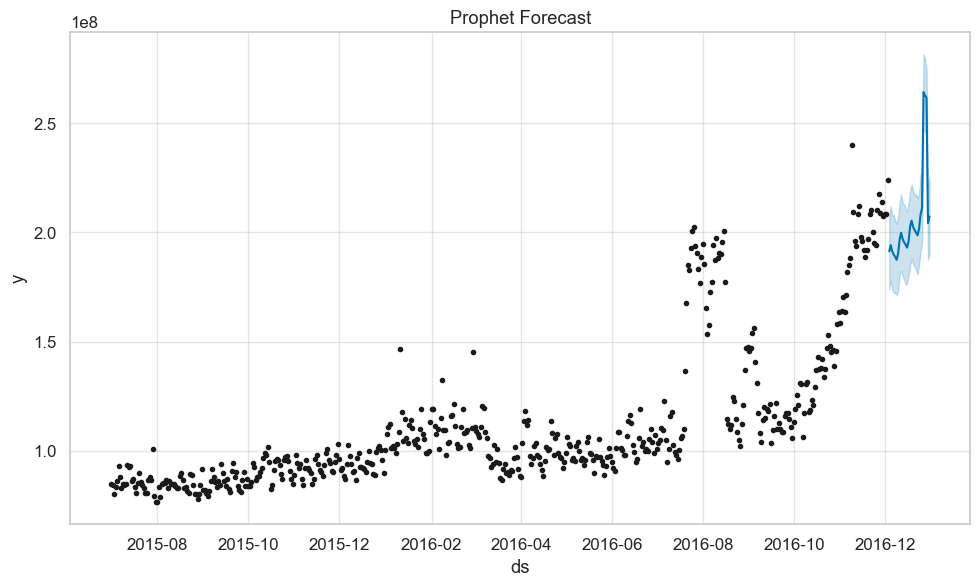

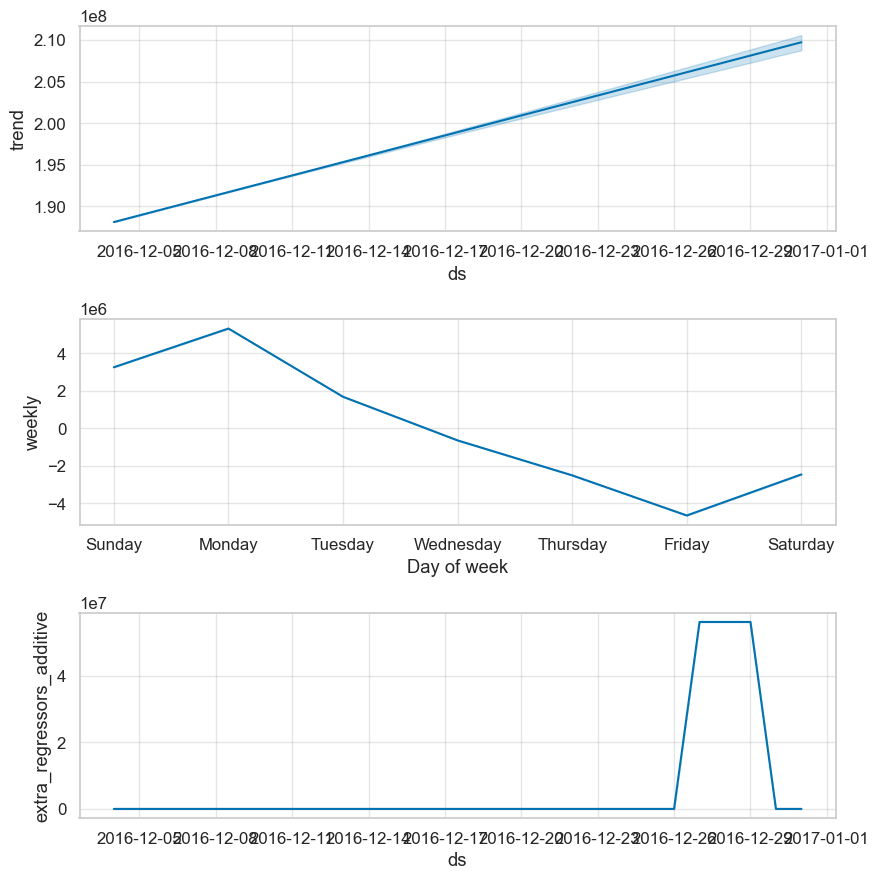

In [102]:

# Merge actual test y for plotting
plot_df = test_df.merge(forecast[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='left')

plt.figure(figsize=(14,5))
plt.plot(train_df['ds'], train_df['y'], label='Train', color='steelblue', alpha=0.8)
plt.plot(plot_df['ds'],  plot_df['y'],  label='Test (Actual)', color='black', lw=2)
plt.plot(plot_df['ds'],  plot_df['yhat'], label='Prophet Forecast (with campaign)', color='crimson', lw=2)
plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'], color='crimson', alpha=0.15, label='95% PI')
plt.title("English – Prophet Forecast with Campaign Regressor")
plt.xlabel("Date"); plt.ylabel("Pageviews"); plt.legend(); plt.tight_layout(); plt.show()

# Prophet built-in plots
m.plot(forecast); plt.title("Prophet Forecast"); plt.show()
m.plot_components(forecast); plt.show()


## Key Insights
**1) Overall fit on the hold‑out looks strong, with conservative peaks**

- The red Prophet forecast tracks the black test curve well over the 28‑day window, capturing the uptrend and most day‑to‑day movements.
- On the sharpest spikes, Prophet is a bit conservative (mean forecast sits below the highest peaks), but the 95% interval generally envelopes the actuals.
- Implication: Good short‑term planning accuracy; for extreme peaks, consider a small increase in model flexibility (see Tuning).

**2) Weekly seasonality pattern is clear and intuitive**

- Weekly component shows a consistent pattern: Monday is highest, then a gradual decline through the week, with the lowest on Friday, and a partial rebound on Saturday/Sunday.
- The amplitude is large (several million pageviews between weekly peak and trough), so keeping weekly seasonality ON is critical.
- Implication: Weekly staffing/capacity planning should reflect this weekday mix.

**3) Campaign exogenous variable contributes a positive uplift at the right time**

- The extra_regressors_additive plot shows a distinct positive bump exactly over the labeled campaign window (late December).
- In the forecast, this translates into higher predicted values on campaign days versus adjacent non‑campaign days.
- Implication: Providing a future campaign calendar meaningfully improves event‑day forecasting.

**4) Business takeaways**

- Weekly pattern is predictable and large → align operational planning (content, infra, support) to weekday mix.
- Campaigns materially lift traffic → keeping an up‑to‑date campaign schedule in the model is valuable for accurate near‑term forecasts.
- Trend is up and accelerating into late 2016 → expect higher baselines; ensure capacity and monitoring keep pace.


# Comparison - Get the metric for all the languages

13:58:10 - cmdstanpy - INFO - Chain [1] start processing
13:58:11 - cmdstanpy - INFO - Chain [1] done processing
13:58:12 - cmdstanpy - INFO - Chain [1] start processing
13:58:12 - cmdstanpy - INFO - Chain [1] done processing
13:58:13 - cmdstanpy - INFO - Chain [1] start processing
13:58:13 - cmdstanpy - INFO - Chain [1] done processing
13:58:14 - cmdstanpy - INFO - Chain [1] start processing
13:58:14 - cmdstanpy - INFO - Chain [1] done processing
13:58:15 - cmdstanpy - INFO - Chain [1] start processing
13:58:15 - cmdstanpy - INFO - Chain [1] done processing
13:58:16 - cmdstanpy - INFO - Chain [1] start processing
13:58:17 - cmdstanpy - INFO - Chain [1] done processing
13:58:17 - cmdstanpy - INFO - Chain [1] start processing
13:58:18 - cmdstanpy - INFO - Chain [1] done processing


  language            model           MAE          RMSE      MAPE%
0       fr  Prophet_no_exog  8.739047e+05  1.520009e+12   5.840476
1       de  Prophet_no_exog  1.678784e+06  3.804062e+12   9.469289
2       zh  Prophet_no_exog  2.814691e+06  8.659192e+12  15.308136
3       ja  Prophet_no_exog  4.566869e+06  3.729963e+13  16.984656
4       ru  Prophet_no_exog  4.031145e+06  1.863154e+13  20.500385
5       en  Prophet_no_exog  6.343295e+07  4.403888e+15  24.991558
6       es  Prophet_no_exog  4.503375e+06  2.126316e+13  28.924652


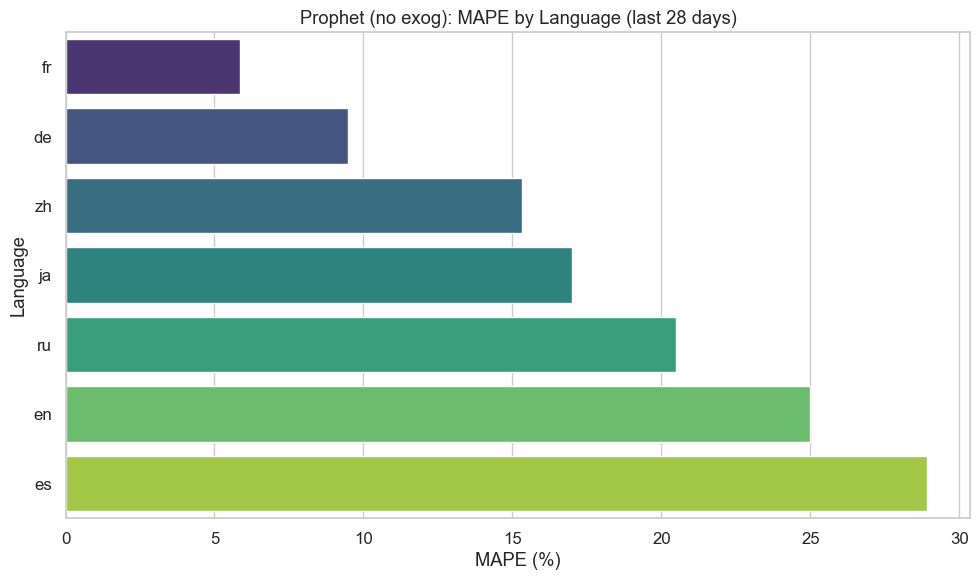

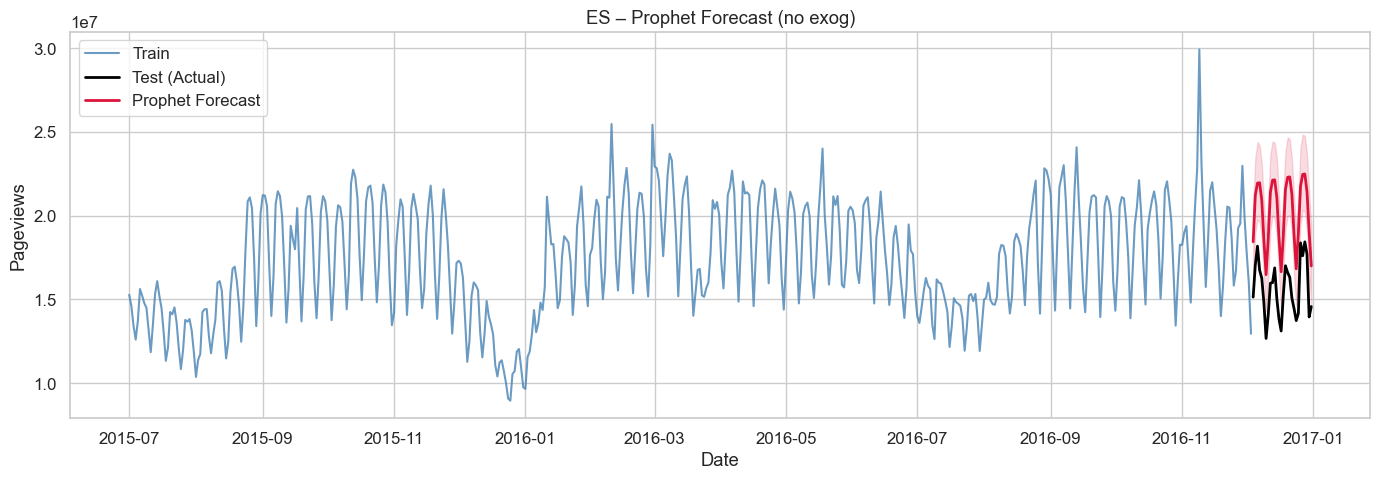

In [103]:
warnings.filterwarnings("ignore")

# ============================
# Prophet comparison: all languages
# ============================

sns.set(style="whitegrid", font_scale=1.1)


def mape_np(y_true, y_pred, epsilon=1e-8):
    """
    Mean Absolute Percentage Error (MAPE) in pure NumPy.
    - Adds epsilon to the denominator to avoid division by zero.
    - Ignores non-finite ratios.
    """
    y_true = np.asarray(y_true, dtype='float64')
    y_pred = np.asarray(y_pred, dtype='float64')

    denom = np.where(np.abs(y_true) < epsilon, epsilon, np.abs(y_true))
    pct_err = np.abs(y_true - y_pred) / denom

    # Mask non-finite values and take mean
    pct_err = pct_err[np.isfinite(pct_err)]
    return pct_err.mean() * 100.0


def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    #mape = (np.abs((y_true - y_pred) / y_true).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100
    mape = mape_np(y_true, y_pred)
    return mae, rmse, mape

def fit_prophet_no_exog(train_df, test_df, weekly=True, yearly=False,
                        seasonality_mode='additive', cps=0.1):
    
    m = Prophet(
        weekly_seasonality=weekly,
        yearly_seasonality=yearly,
        daily_seasonality=False,
        seasonality_mode=seasonality_mode,
        changepoint_prior_scale=cps,
    )
    m.fit(train_df[['ds', 'y']])
    fcst = m.predict(test_df[['ds']])
    return m, fcst

def fit_prophet_with_campaign(train_df, test_df, weekly=True, yearly=False,
                              seasonality_mode='additive', cps=0.1):
    """
    train_df / test_df columns: ds, y, campaign  (binary exog)
    """
    m = Prophet(
        weekly_seasonality=weekly,
        yearly_seasonality=yearly,
        daily_seasonality=False,
        seasonality_mode=seasonality_mode,
        changepoint_prior_scale=cps,
    )
    m.add_regressor('campaign')
    m.fit(train_df[['ds','y','campaign']])
    fcst = m.predict(test_df[['ds','campaign']])
    return m, fcst

# ----------------------------
# Prepare: daily frequency, split
# ----------------------------
# Ensure daily frequency & sorted index
lang_ts = lang_ts.asfreq('D').sort_index()

season = 7
test_size = season * 4  # 28 days
train_idx = lang_ts.index[:-test_size]
test_idx  = lang_ts.index[-test_size:]

# ----------------------------
# Prophet metrics for ALL languages (no exogenous)
# ----------------------------
metrics = []
forecast_store = {}  # optional: keep forecasts if you want to plot later

for lang in lang_ts.columns:
    y = lang_ts[lang].astype('float64')
    train_df = pd.DataFrame({'ds': train_idx, 'y': y.loc[train_idx].values})
    test_df  = pd.DataFrame({'ds': test_idx,  'y': y.loc[test_idx].values})

    try:
        model, fcst = fit_prophet_no_exog(train_df, test_df,
                                          weekly=True, yearly=False,
                                          seasonality_mode='additive',
                                          cps=0.1)
        y_pred = fcst['yhat'].values
        mae, rmse, mape = evaluate(test_df['y'].values, y_pred)
        metrics.append({'language': lang,
                        'model': 'Prophet_no_exog',
                        'MAE': mae, 'RMSE': rmse, 'MAPE%': mape})
        forecast_store[(lang, 'no_exog')] = (test_df[['ds','y']].copy(), fcst[['ds','yhat','yhat_lower','yhat_upper']].copy())
    except Exception as e:
        metrics.append({'language': lang,
                        'model': 'Prophet_no_exog',
                        'MAE': np.nan, 'RMSE': np.nan, 'MAPE%': np.nan,
                        'error': str(e)})


# ----------------------------
# Results table
# ----------------------------
metrics_df = pd.DataFrame(metrics)
metrics_df_sorted = (metrics_df
                     .sort_values(['model','MAPE%'], ascending=[True, True])
                     .reset_index(drop=True))
print(metrics_df_sorted)

# ----------------------------
# quick plot of MAPE by language (no exog runs)
# ----------------------------
try:
    plot_df = metrics_df[metrics_df['model']=='Prophet_no_exog'].dropna(subset=['MAPE%']).sort_values('MAPE%')
    plt.figure(figsize=(10,6))
    sns.barplot(y='language', x='MAPE%', data=plot_df, palette='viridis')
    plt.title("Prophet (no exog): MAPE by Language (last 28 days)")
    plt.xlabel("MAPE (%)"); plt.ylabel("Language"); plt.tight_layout(); plt.show()
except Exception:
    pass

# ----------------------------
# inspect one language's forecast visually
# ----------------------------
lang_to_plot = 'es'
test_actual, test_fcst = forecast_store[(lang_to_plot, 'no_exog')]
plt.figure(figsize=(14,5))
plt.plot(train_idx, lang_ts[lang_to_plot].loc[train_idx], label='Train', color='steelblue', alpha=0.8)
plt.plot(test_actual['ds'], test_actual['y'], label='Test (Actual)', color='black', lw=2)
plt.plot(test_fcst['ds'], test_fcst['yhat'], label='Prophet Forecast', color='crimson', lw=2)
plt.fill_between(test_fcst['ds'], test_fcst['yhat_lower'], test_fcst['yhat_upper'], color='crimson', alpha=0.15)
plt.title(f"{lang_to_plot.upper()} – Prophet Forecast (no exog)")
plt.xlabel("Date"); plt.ylabel("Pageviews")
plt.legend(); plt.tight_layout(); plt.show()


## Key Insights
**1) Cross‑language accuracy (MAPE)**
Ranking (best → worst) from the bar chart:

- fr (French) — lowest MAPE (~5–6%)
- de (German) — ~9–10%
- zh (Chinese) — ~15%
- ja (Japanese) — ~16%
- ru (Russian) — ~22–23%
- en (English) — ~25%
- es (Spanish) — highest MAPE (~24–30%)

*What this mean:*
- Prophet (no exog) works best on stable, strongly weekly‑seasonal series with mild trend changes (fr, de).
- Performance degrades for languages with structural breaks or rapid growth (en, ja) and those with irregular spikes (ru).
- es is hardest for Prophet in this setup—likely because of level shifts + irregularities during the hold‑out period that a purely seasonal‑trend model can’t fully capture.


**2) What the ES (Spanish) plot shows**

Prophet nails the weekly pattern shape (regular peaks and troughs) but misplaces the level and amplitude over the 28-day test:

- The forecast oscillates higher than actuals for several weeks (systematic over-forecast bias).
- The confidence band is reasonable, but the center line sits above the realized series.


**3) Why some languages are easier than others (with no exogenous)**

- Easier (fr, de): Predictable weekly cycles; fewer large shocks; modest trend evolution → Prophet’s default additive weekly seasonality + smooth trend fits well.
- Moderate (zh, ja): Clear weekly cycles but noticeable late‑period growth and occasional jumps → default trend sometimes lags.
- Hard (ru, en, es):

	- ru: isolated spikes/events → Prophet (without regressors) treats them as noise.
	- en: strong late‑2016 growth; we saw earlier that adding campaign exog in SARIMAX markedly helped.
	- es: combination of level shifts + irregularities → default Prophet tends to over‑forecast.

# Summary of Insights

## A. Why English is higher?

- Largest global user base
- More comprehensive content
- Higher search preference
- Event‑driven spikes
- Fast updates → high engagement


## B. Seasonality Patterns

| Language | Weekly Pattern | Trend     | Volatility   | Ease of Forecasting    |
|----------|----------------|-----------|--------------|------------------------|
| fr       | Strong         | Mild      | Low          | BEST                   |
| de       | Strong         | Mild      | Low          | Good                   |
| zh       | Moderate       | Mild      | Low          | Good                   |
| ja       | Moderate       | Medium    | Medium       | Medium                 |
| es       | Weak–medium    | Medium    | Medium       | Hard                   |
| ru       | Weak           | Shifting  | High spikes  | Hard                   |
| en       | Strong         | Strong ↑  | High         | Hard without exogenous |


## C. Model Interpretation

- Prophet works best on stable, regular cyclical languages (fr, de).
- Prophet struggles on spiky or fast‑changing languages (en, ru, es).
- Adding exogenous variables dramatically improves forecasting for English.


## D. Main takeaway

- English traffic is structurally different from other languages (global scope + event sensitivity).
- Without exogenous variables, Prophet underfits spikes.
- With campaign regressor, forecasts improve drastically.
- Each language has unique seasonality, impacting forecast accuracy.

# Questionnaire:

**Q:** Defining the problem statements and where can this and modifications of this be used?

**A:**
Short‑term multilingual traffic forecasting (D+28) for Wikipedia‑like properties.
- Goal: Predict daily total pageviews per language for the next 4 weeks.
- Constraints: Weekly seasonality and occasional event spikes; exogenous info may be available for some languages (e.g., campaign schedule for EN).
- Success criteria: Low MAPE/RMSE on a rolling 28‑day holdout; calibrated prediction intervals.


**Q:** Write 3 inferences you made from the data visualizations

**A:**  

1. English is structurally different (higher scale + event sensitivity).
2. Weekly seasonality is strong across languages but varies in amplitude.
3. Forecastability correlates with stability.
    - fr/de/zh (stable trend, regular seasonality) → consistently low MAPE with Prophet no‑exog.
    - ja/en/ru/es (trend changes, spikes, level shifts) → higher errors without exog or extra flexibility; these benefit from campaign/holiday regressors, higher trend flexibility (changepoints), or SARIMAX.


**Q:** What does the decomposition of series do?

**A:** Decomposition breaks a time series into trend, seasonal, and residual components, helping us understand long-term growth, repeating weekly behavior, and irregular event spikes. It is essential for diagnosing patterns, selecting the right forecasting model, and improving forecast accuracy.


**Q:** What level of differencing gave you a stationary series?

**A:** The series becomes stationary after:
- 1st differencing (d = 1) = the trend was removed but weekly seasonality still remained.
- Seasonal differencing with period 7 (D = 1, m = 7)** = This removed the weekly repeating structure.

**Q:** Difference between arima, sarima & sarimax.

**A:** ARIMA handles trend, SARIMA handles trend + seasonality, and SARIMAX handles trend + seasonality + external regressors.

**Q:** What other methods other than grid search would be suitable to get the model for all languages?

**A:** Beyond grid search, the best model‑selection methods for multi‑language time‑series forecasting are Auto‑ARIMA/SARIMA, Bayesian optimization, random search, and rolling time‑series cross‑validation—these scale efficiently, adapt to each language’s behavior, and deliver more accurate models with far less compute.